In [29]:
%reset -f

In [ ]:
%reload_ext autoreload
%autoreload 2

# todo
cust_name = 'cust1'
data1 = 'deltaV1'
data2 = 'thetaV2'
data3 = 'zetaV2'

# name1 = data1+'_'+cust_name
# name2 = data2+'_'+cust_name
# name3 = data3+'_'+cust_name
ronghe_name = 'ronghe'+'_'+cust_name

import sys
sys.path.append(r"D:\work\scorecard") 
FILE_PATH = rf'D:\HelloBike\{ronghe_name}\file/'
DATA_PATH = rf'D:\HelloBike\{ronghe_name}\data/'
DATA_PATH_name1 = rf'D:\HelloBike\{data1}\{cust_name}\data/'
DATA_File_name1 = rf'D:\HelloBike\{data1}\{cust_name}\file/'
DATA_PATH_name2 = rf'D:\HelloBike\{data2}\{cust_name}\data/'
DATA_PATH_name3 = rf'D:\HelloBike\{data3}\{cust_name}\data/'
TMP_PATH  = rf'D:\HelloBike\{ronghe_name}\tmp/'

import os
import pandas as pd 
import numpy as np  
import math  
import matplotlib.pyplot as plt
import copy
import seaborn as sns
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False  

isExists=os.path.exists(FILE_PATH)
if not isExists:
    os.makedirs(FILE_PATH) 
    
isExists=os.path.exists(DATA_PATH)
if not isExists:
    os.makedirs(DATA_PATH) 

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# config cell
epoch = 2000
# split_flag = 2025
split_flag = pd.read_csv(DATA_File_name1 + 'best_flag.csv')['best_flag'].tolist()[0]

In [ ]:
data_name1 = pd.read_csv(DATA_PATH_name1 + '打分文件.csv', usecols=['mobile', 'backDateTime', 'proba','label','stage'])
data_name1.rename(columns={'proba':f'proba_{data_name1}'}, inplace=True)
data_name1 = data_name1.drop_duplicates(subset=['mobile', 'backDateTime'], keep='first')
data_name1.reset_index(drop=True, inplace=True)
data_name1

,mobile_sha256,stage,hs_date,label,proba_name1
0,d45735e2015b20c4e8f95645096ae0dac3c9924b9e6b35...,test,2024-11-21,0.0,0.398856
1,dff94df987f14dd7304d25f291729f0b4926adad0df39b...,test,2024-12-02,0.0,0.368966
2,4d4d2304e9265b029491e1fec60e7431d55285fcad426e...,train,2024-10-03,0.0,0.272476
3,f05c3b1367d78a5da0b060110d8724e72664c86dc456a4...,train,2024-10-24,0.0,0.391101
4,d92c8174bf3dd98aa5d11edefef13f24512c53b694071d...,test,2025-01-10,0.0,0.436963
...,...,...,...,...,...
999995,d928ce238b02f72f4bbae368f12731c0bf887313baac65...,test,2024-11-09,0.0,0.415033
999996,d7a90c7b916cafb0078220bb8c97bf00cbb828de347f11...,train,2024-10-16,0.0,0.237734
999997,6cb28ddff4ce98f7ae111971815b6c94f2184ca9246f14...,train,2024-10-17,0.0,0.305189
999998,7d30c49e60d00f75b1437c3eb3cafafd2cbe195fa0885b...,train,2024-09-11,0.0,0.401823


In [ ]:
data_name2 = pd.read_csv(DATA_PATH_name2 + '打分文件.csv',usecols=['mobile', 'backDateTime', 'proba'])
data_name2.rename(columns={'proba':f'proba_{data_name2}'}, inplace=True)
data_name2 = data_name2.drop_duplicates(subset=['mobile', 'backDateTime'], keep='first')
data_name2.reset_index(drop=True, inplace=True)
data_name2

,mobile_sha256,hs_date,proba_name2
0,d45735e2015b20c4e8f95645096ae0dac3c9924b9e6b35...,2024-11-21,0.049736
1,dff94df987f14dd7304d25f291729f0b4926adad0df39b...,2024-12-02,0.056250
2,4d4d2304e9265b029491e1fec60e7431d55285fcad426e...,2024-10-03,0.048015
3,f05c3b1367d78a5da0b060110d8724e72664c86dc456a4...,2024-10-24,0.023600
4,d92c8174bf3dd98aa5d11edefef13f24512c53b694071d...,2025-01-10,0.062824
...,...,...,...
999995,d928ce238b02f72f4bbae368f12731c0bf887313baac65...,2024-11-09,0.036559
999996,d7a90c7b916cafb0078220bb8c97bf00cbb828de347f11...,2024-10-16,0.019517
999997,6cb28ddff4ce98f7ae111971815b6c94f2184ca9246f14...,2024-10-17,0.028223
999998,7d30c49e60d00f75b1437c3eb3cafafd2cbe195fa0885b...,2024-09-11,0.057474


In [ ]:
data_name3 = pd.read_csv(DATA_PATH_name3 + '打分文件.csv',usecols=['mobile', 'backDateTime', 'proba'])
data_name3.rename(columns={'proba':f'proba_{data_name3}'}, inplace=True)
data_name3 = data_name3.drop_duplicates(subset=['mobile', 'backDateTime'], keep='first')
data_name3.reset_index(drop=True, inplace=True)
data_name3

In [ ]:
data_all = pd.merge( data_name1, data_name2, on=['mobile', 'backDateTime'], how = 'left')
data_all.reset_index(drop=True, inplace=True)
data_all

,mobile_sha256,stage,hs_date,label,proba_name1,proba_name2,target
0,d45735e2015b20c4e8f95645096ae0dac3c9924b9e6b35...,test,2024-11-21,0.0,0.398856,0.049736,train
1,dff94df987f14dd7304d25f291729f0b4926adad0df39b...,test,2024-12-02,0.0,0.368966,0.056250,train
2,4d4d2304e9265b029491e1fec60e7431d55285fcad426e...,train,2024-10-03,0.0,0.272476,0.048015,train
3,f05c3b1367d78a5da0b060110d8724e72664c86dc456a4...,train,2024-10-24,0.0,0.391101,0.023600,train
4,d92c8174bf3dd98aa5d11edefef13f24512c53b694071d...,test,2025-01-10,0.0,0.436963,0.062824,train
...,...,...,...,...,...,...,...
999995,d928ce238b02f72f4bbae368f12731c0bf887313baac65...,test,2024-11-09,0.0,0.415033,0.036559,train
999996,d7a90c7b916cafb0078220bb8c97bf00cbb828de347f11...,train,2024-10-16,0.0,0.237734,0.019517,train
999997,6cb28ddff4ce98f7ae111971815b6c94f2184ca9246f14...,train,2024-10-17,0.0,0.305189,0.028223,train
999998,7d30c49e60d00f75b1437c3eb3cafafd2cbe195fa0885b...,train,2024-09-11,0.0,0.401823,0.057474,train


In [ ]:
data_all = pd.merge( data_all, data_name3, on=['mobile', 'backDateTime'], how = 'left')
data_all.reset_index(drop=True, inplace=True)
data_all['target'] = 'train'
data_all

,mobile_sha256,stage,hs_date,label,proba_name1,proba_name2,target
0,d45735e2015b20c4e8f95645096ae0dac3c9924b9e6b35...,test,2024-11-21,0.0,0.398856,0.049736,train
1,dff94df987f14dd7304d25f291729f0b4926adad0df39b...,test,2024-12-02,0.0,0.368966,0.056250,train
2,4d4d2304e9265b029491e1fec60e7431d55285fcad426e...,train,2024-10-03,0.0,0.272476,0.048015,train
3,f05c3b1367d78a5da0b060110d8724e72664c86dc456a4...,train,2024-10-24,0.0,0.391101,0.023600,train
4,d92c8174bf3dd98aa5d11edefef13f24512c53b694071d...,test,2025-01-10,0.0,0.436963,0.062824,train
...,...,...,...,...,...,...,...
999995,d928ce238b02f72f4bbae368f12731c0bf887313baac65...,test,2024-11-09,0.0,0.415033,0.036559,train
999996,d7a90c7b916cafb0078220bb8c97bf00cbb828de347f11...,train,2024-10-16,0.0,0.237734,0.019517,train
999997,6cb28ddff4ce98f7ae111971815b6c94f2184ca9246f14...,train,2024-10-17,0.0,0.305189,0.028223,train
999998,7d30c49e60d00f75b1437c3eb3cafafd2cbe195fa0885b...,train,2024-09-11,0.0,0.401823,0.057474,train


In [ ]:
data_all[[f'proba_{data_name3}',f'proba_{data_name2}', f'proba_{data_name1}']].corr()

,proba_name2,proba_name1
proba_name2,1.000000,0.483459
proba_name1,0.483459,1.000000


### 划分数据集

In [ ]:
from DataPreprocessing.Datasets.Describe import badrate_by_month

month_time = badrate_by_month(data_all, 'backDateTime', ['train'], 'label')
month_time

,count,bad,good,bad_rate
2024-09,200000,4269.0,195731.0,0.021345
2024-10,300000,5813.0,294187.0,0.019377
2024-11,300000,5446.0,294554.0,0.018153
2024-12,100000,1857.0,98143.0,0.018570
2025-01,100000,2574.0,97426.0,0.025740


In [37]:
data_all['target'] = 'train'
data_all.loc[((data_all['stage']) == 'test') & (data_all['target'] =='train'),'target'] = 'oot'

In [38]:
data_all['target'].value_counts()

oot      526883
train    473117
Name: target, dtype: int64

In [ ]:
from DataPreprocessing.Datasets.Split import by_stratify
data_all, res = by_stratify(data_all.fillna(-999), 0.3, split_flag, date='backDateTime', dep='label')

         count  bad_rate      bad    time_min    time_max
all    1000000  0.019959  19959.0  2024-09-01  2025-01-31
train   331181  0.020167   6679.0  2024-09-01  2024-10-28
valid   141936  0.020171   2863.0  2024-09-01  2024-10-28
oot     526883  0.019771  10417.0  2024-10-29  2025-01-31
ratio_bad_good:  0.020582307659120745
oot      526883
train    331181
valid    141936
Name: target, dtype: int64


In [ ]:
data_all['weight'] =1
ex_lst = ['mobile', 'stage', 'label', 'backDateTime', 'target', 'month_time', 'weight']

ft_lst = [i for i in data_all.columns if i not in ex_lst]
print('num_feature: ', len(ft_lst))
print('data_shape: ', data_all.shape)
ft_lst

num_feature:  2
data_shape:  (1000000, 9)


['proba_name1', 'proba_name2']

In [41]:
import sys
sys.version

'3.8.19 (default, Mar 20 2024, 19:55:45) [MSC v.1916 64 bit (AMD64)]'

In [42]:
from ScoreCard.creat_report import Report

for i in range(0,(len(ft_lst) // 1000) + 1):
    start, end = i * 1000, min((i + 1) * 1000, len(ft_lst))
    print(start, ' - ', end)
    report = Report(data_all[ft_lst[start:end] + ex_lst], ex_lst, 'label', FILE_PATH + str(i) + '_')
    key_value, bins_detail = report.iv_ks_psi_chi2_missing_quantile()

0  -  2
正在计算IV......
正在计算CHI2......
正在计算COVER RATE......
正在计算QUANTILE......
正在保存结果......
已保存


In [43]:
import os
files_key_value, files_bins_detail = [], []
for root, dirs, files in os.walk(FILE_PATH[:-1]): 
    for file in files:
        if '_bins_detail' in file:
            files_bins_detail.append(pd.read_excel(root +'/'+ file))
        elif 'iv_ipt_psi_chi2_missing' in file:
            files_key_value.append(pd.read_excel(root +'/'+ file))
            
key_value = pd.concat(files_key_value)
bins_detail = pd.concat(files_bins_detail)

bins_detail.to_excel(FILE_PATH + 'bins_detail.xlsx')
key_value.to_excel(FILE_PATH + 'key_value.xlsx')

In [44]:
key_value.sort_values(by='iv_bin_train', ascending=False)

,Unnamed: 0,var_names,ks,iv_bin_train,iv_bin_valid,iv_bin_oot,iv_bin_total,psi_tv_bin,psi_to_bin,psi_tvo_bin,...,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,max
1,1,proba_name1,0.192108,0.273367,0.201221,0.192727,0.217356,0.000047,0.002282,0.002197,...,0.257103,0.289756,0.327141,0.361182,0.386915,0.415033,0.415033,0.444117,0.562521,0.704663
0,0,proba_name2,0.208659,0.270393,0.266396,0.209457,0.236685,0.000052,0.003153,0.003207,...,0.029137,0.033405,0.037724,0.042209,0.047089,0.052698,0.059847,0.065809,0.083774,0.330222


In [45]:
data_all.fillna(-999).to_csv(DATA_PATH + 'data_ft_2.csv', index=False, encoding='utf-8-sig')

num_features:  2
逻辑回归：
  datasets       auc  precision    recall        ks        f2        th  \
0      oot  0.645828   0.034751  0.421811  0.210199  0.130689  0.574702   
0    valid  0.655458   0.036005  0.477471  0.231740  0.138307  0.563368   
0    train  0.667109   0.038243  0.452613  0.241955  0.142912  0.573240   

      ratio   count  
0  0.239979  526883  
0  0.267494  141936  
0  0.238685  331181  
  datasets       auc        ks  precision    recall        f2        th  \
0      oot  0.645828  0.210199   0.034751  0.421811  0.130689  0.574702   
0    valid  0.655458  0.231740   0.036005  0.477471  0.138307  0.563368   
0    train  0.667109  0.241955   0.038243  0.452613  0.142912  0.573240   

      ratio   count  
0  0.239979  526883  
0  0.267494  141936  
0  0.238685  331181  


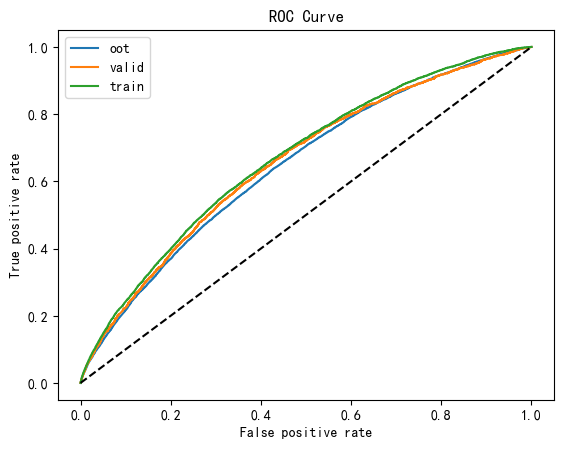

XGBoost：
  datasets       auc  precision    recall        ks        f2        th  \
0      oot  0.648773   0.034290  0.452050  0.220213  0.131538  0.025853   
0    valid  0.660711   0.038100  0.433811  0.239621  0.140976  0.027995   
0    train  0.674355   0.041351  0.395269  0.256152  0.145759  0.029194   

      ratio   count  
0  0.260646  526883  
0  0.229667  141936  
0  0.192777  331181  
  datasets       auc        ks  precision    recall        f2        th  \
0      oot  0.648773  0.220213   0.034290  0.452050  0.131538  0.025853   
0    valid  0.660711  0.239621   0.038100  0.433811  0.140976  0.027995   
0    train  0.674355  0.256152   0.041351  0.395269  0.145759  0.029194   

      ratio   count  
0  0.260646  526883  
0  0.229667  141936  
0  0.192777  331181  


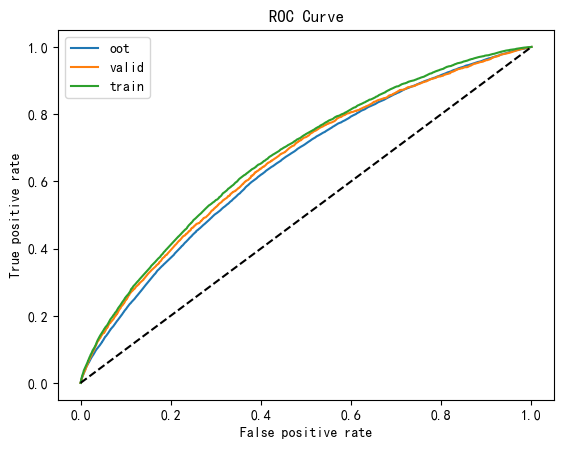

LightGBM：
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
  datasets       auc  precision    recall        ks        f2        th  \
0      oot  0.649494   0.034973  0.434962  0.220098  0.132312  0.026357   
0    valid  0.661053   0.038395  0.425079  0.240900  0.141023  0.027769   
0    train  0.673056   0.040213  0.419075  0.256849  0.145297  0.028256   

      ratio   count  
0  0.245891  526883  
0  0.223319  141936  
0  0.210169  331181  
  datasets       auc        ks  precision    recall        f2        th  \
0      oot  0.649494  0.220098   0.034973  0.434962  0.132312  0.026357   
0    valid  0.661053  0.240900   0.038395  0.425079  0.141023  0.027769   
0    train  0.673056  0.256849   0.040213  0.419075  0.145297  0.028256   

      ratio   count  
0  0.245891  526883  
0  0.223319  141936  


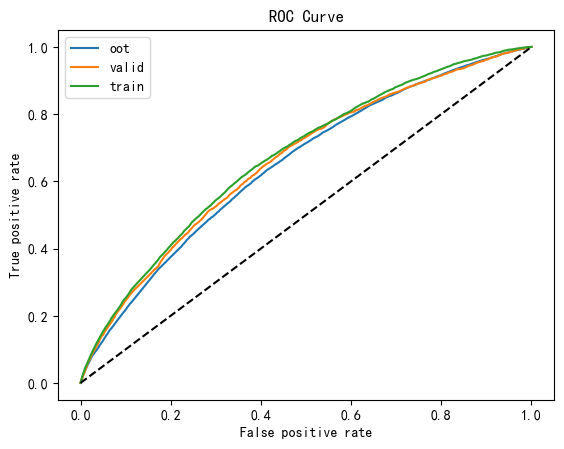

In [46]:
from Model.train import bi_train
res =  bi_train(data_all.fillna(-999), dep='label', exclude=ex_lst, model_switch=[1, 1, 1, 0])

In [ ]:
from DataPreprocessing.Datasets.Split import by_stratify
data_all, res = by_stratify(data_all.fillna(-999), 0.3, split_flag, date='backDateTime', dep='label')

         count  bad_rate      bad    time_min    time_max
all    1000000  0.019959  19959.0  2024-09-01  2025-01-31
train   331181  0.020167   6679.0  2024-09-01  2024-10-28
valid   141936  0.020171   2863.0  2024-09-01  2024-10-28
oot     526883  0.019771  10417.0  2024-10-29  2025-01-31
ratio_bad_good:  0.020582307659120745
oot      526883
train    331181
valid    141936
Name: target, dtype: int64


num_features:  2
逻辑回归：
  datasets       auc  precision    recall        ks        f2        th  \
0      oot  0.645828   0.034751  0.421811  0.210199  0.130689  0.574702   
0    valid  0.655458   0.036005  0.477471  0.231740  0.138307  0.563368   
0    train  0.667109   0.038243  0.452613  0.241955  0.142912  0.573240   

      ratio   count  
0  0.239979  526883  
0  0.267494  141936  
0  0.238685  331181  
  datasets       auc        ks  precision    recall        f2        th  \
0      oot  0.645828  0.210199   0.034751  0.421811  0.130689  0.574702   
0    valid  0.655458  0.231740   0.036005  0.477471  0.138307  0.563368   
0    train  0.667109  0.241955   0.038243  0.452613  0.142912  0.573240   

      ratio   count  
0  0.239979  526883  
0  0.267494  141936  
0  0.238685  331181  


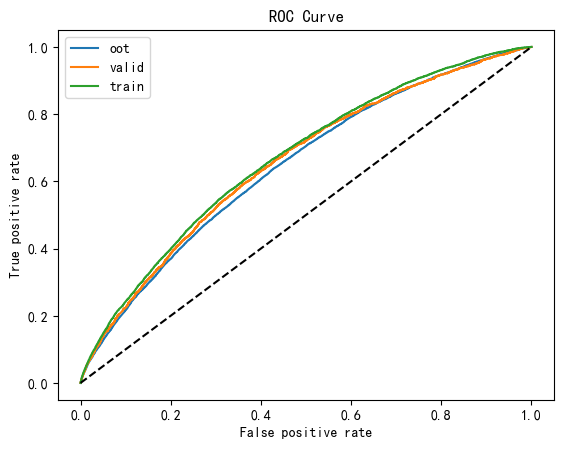

XGBoost：
  datasets       auc  precision    recall        ks        f2        th  \
0      oot  0.648773   0.034290  0.452050  0.220213  0.131538  0.025853   
0    valid  0.660711   0.038100  0.433811  0.239621  0.140976  0.027995   
0    train  0.674355   0.041351  0.395269  0.256152  0.145759  0.029194   

      ratio   count  
0  0.260646  526883  
0  0.229667  141936  
0  0.192777  331181  
  datasets       auc        ks  precision    recall        f2        th  \
0      oot  0.648773  0.220213   0.034290  0.452050  0.131538  0.025853   
0    valid  0.660711  0.239621   0.038100  0.433811  0.140976  0.027995   
0    train  0.674355  0.256152   0.041351  0.395269  0.145759  0.029194   

      ratio   count  
0  0.260646  526883  
0  0.229667  141936  
0  0.192777  331181  


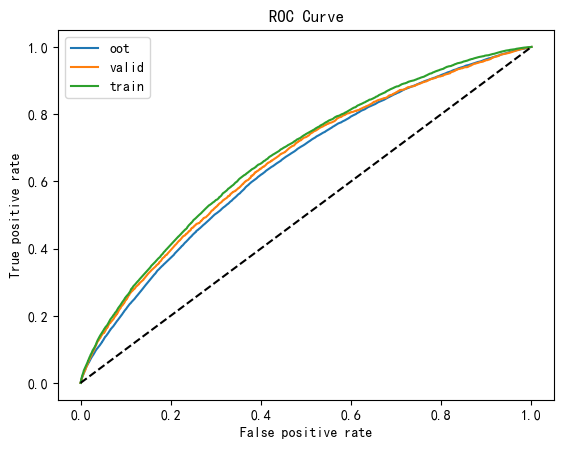

LightGBM：
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
  datasets       auc  precision    recall        ks        f2        th  \
0      oot  0.649494   0.034973  0.434962  0.220098  0.132312  0.026357   
0    valid  0.661053   0.038395  0.425079  0.240900  0.141023  0.027769   
0    train  0.673056   0.040213  0.419075  0.256849  0.145297  0.028256   

      ratio   count  
0  0.245891  526883  
0  0.223319  141936  
0  0.210169  331181  
  datasets       auc        ks  precision    recall        f2        th  \
0      oot  0.649494  0.220098   0.034973  0.434962  0.132312  0.026357   
0    valid  0.661053  0.240900   0.038395  0.425079  0.141023  0.027769   
0    train  0.673056  0.256849   0.040213  0.419075  0.145297  0.028256   

      ratio   count  
0  0.245891  526883  
0  0.223319  141936  


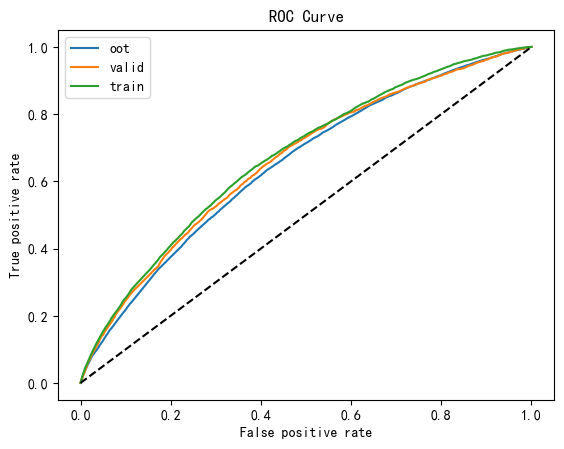

In [48]:
from Model.train import bi_train
res =  bi_train(data_all, dep='label', exclude=ex_lst, model_switch=[1, 1, 1, 0])

In [49]:
keep_lst = ft_lst
data_end = data_all[keep_lst + ex_lst].copy()
len(keep_lst)

2

In [50]:
from ParameterRegulation.Optuna import run, objective_fix_sample
file_path = FILE_PATH + 'optuna_xgb.xlsx'
print('epoch = ',epoch)
res_opt = run(objective_fix_sample, data_end, ex_lst,  1348, file_path, epoch, 'xgb',max_depth=3)

[I 2025-08-29 15:01:06,243] A new study created in memory with name: no-name-b751e112-d77d-4d8d-8a6a-13971b207c85


epoch =  2000


[I 2025-08-29 15:01:08,935] Trial 0 finished with value: 0.22161859276245519 and parameters: {'reg_lambda': 7.516824112399343e-06, 'reg_alpha': 0.8502000454807829, 'n_estimators': 46, 'max_depth': 1, 'min_child_weight': 2, 'learning_rate': 0.02007119791403639, 'col_sample_bytree': 0.5508762975087961, 'scale_pos_weight': 4.200520999510562, 'gamma': 0.022320793045414362, 'subsample': 0.8545594452510142}. Best is trial 0 with value: 0.22161859276245519.
[I 2025-08-29 15:01:11,988] Trial 1 finished with value: 0.23072835187392535 and parameters: {'reg_lambda': 36.632845013565834, 'reg_alpha': 2.4230361269662976e-06, 'n_estimators': 88, 'max_depth': 3, 'min_child_weight': 2, 'learning_rate': 0.04924071939837685, 'col_sample_bytree': 0.11032151000804653, 'scale_pos_weight': 6.1003638031873155, 'gamma': 0.0008567906214311005, 'subsample': 0.5903136966010009}. Best is trial 1 with value: 0.23072835187392535.
[I 2025-08-29 15:01:14,339] Trial 2 finished with value: 0.2092484145296845 and parame

FrozenTrial(number=1940, state=TrialState.COMPLETE, values=[0.23452305038510923], datetime_start=datetime.datetime(2025, 8, 29, 16, 17, 56, 454911), datetime_complete=datetime.datetime(2025, 8, 29, 16, 17, 59, 350774), params={'reg_lambda': 0.13800524774316475, 'reg_alpha': 1.4650529722520026e-05, 'n_estimators': 81, 'max_depth': 2, 'min_child_weight': 18, 'learning_rate': 0.08025423867704903, 'col_sample_bytree': 0.3128735934554654, 'scale_pos_weight': 10.177942010712941, 'gamma': 2.6798913400415537e-07, 'subsample': 0.6222175673706043}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'reg_lambda': FloatDistribution(high=500.0, log=True, low=1e-08, step=None), 'reg_alpha': FloatDistribution(high=1.0, log=True, low=1e-08, step=None), 'n_estimators': IntDistribution(high=100, log=True, low=30, step=1), 'max_depth': IntDistribution(high=3, log=False, low=1, step=1), 'min_child_weight': IntDistribution(high=50, log=True, low=1, step=1), 'learning_rate': FloatDistrib

In [51]:
ress_xgb = pd.read_excel(FILE_PATH + 'optuna_xgb.xlsx')
if 'oot_ks' in ress_xgb.columns:
    res = ress_xgb[ress_xgb['valid_ks'] > 0.1][['train_ks', 'valid_ks', 'oot_ks', 'oot_if_badrate_mono']]
    res = res[res['train_ks'] > 0.1]
    res = res[res['oot_ks'] > 0.1]
    res['delta'] = res['train_ks'] - res['oot_ks']
    res['delta1'] = res['valid_ks'] - res['oot_ks']
    res['delta2'] = res['valid_ks'] - res['train_ks']
    #res = res[abs(res['delta']) < 0.03]
    #res = res[abs(res['delta1']) < 0.03]
    #res = res[abs(res['delta2']) < 0.03]
    #res = res[res['oot_if_badrate_mono']==1]
    res.sort_values(by='oot_ks', ascending=False, inplace=True)
else:
    res = ress_xgb[ress_xgb['valid_ks'] > 0.27][['train_ks', 'valid_ks']]
    res = res[res['train_ks'] > 0.27]
    res['delta2'] = res['valid_ks'] - res['train_ks']
    res = res[abs(res['delta2']) < 0.03]
    res.sort_values(by='oot_ks', ascending=False, inplace=True)
res_xgb = res.copy()
res_xgb

,train_ks,valid_ks,oot_ks,oot_if_badrate_mono,delta,delta1,delta2
354,0.256321,0.241002,0.222815,True,0.033506,0.018188,-0.015319
942,0.256268,0.239726,0.222490,True,0.033777,0.017236,-0.016542
1404,0.257826,0.241580,0.222481,True,0.035345,0.019099,-0.016246
294,0.257005,0.241490,0.222435,True,0.034570,0.019055,-0.015515
19,0.259220,0.238499,0.222425,True,0.036795,0.016074,-0.020721
...,...,...,...,...,...,...,...
6,0.249910,0.230505,0.212517,False,0.037393,0.017988,-0.019406
36,0.238593,0.236196,0.210340,False,0.028253,0.025856,-0.002397
0,0.238636,0.233360,0.209877,False,0.028759,0.023484,-0.005276
8,0.245404,0.226022,0.209072,False,0.036332,0.016950,-0.019382


In [52]:
res_xgb.to_csv(DATA_PATH + 'res_model_xgb.csv')

In [53]:
FILE_PATH

'D:\\work\\03.poc\\01-马上消费\\AlphaV3-ThetaV2_CA_target1\\file/'

In [54]:
params = eval(ress_xgb.iloc[res_xgb.index[0]]['model_param'])
params

{'verbosity': 0,
 'booster': 'gbtree',
 'reg_lambda': 0.0014453767189378805,
 'reg_alpha': 0.3504892035256494,
 'n_estimators': 77,
 'max_depth': 2,
 'min_child_weight': 15,
 'learning_rate': 0.12284111702199724,
 'col_sample_bytree': 0.14840427036180234,
 'scale_pos_weight': 12.606976155760012,
 'gamma': 0.0001331683459538828,
 'subsample': 0.6846160380643508}

In [55]:
from Model.train import show
import xgboost as xgb
nan = np.nan



print('num_features: ', len(keep_lst))
model = xgb.XGBClassifier(**params)

model.fit(data_end[data_end['target'] == 'train'][keep_lst], 
          data_end[data_end['target'] == 'train']['label'], 
          sample_weight=data_end[data_end['target'] == 'train']['weight'])

import joblib
#lr是一个LogisticRegression模型
joblib.dump(model, 'model.model')
model = joblib.load('model.model')
pd.DataFrame({'var_names':keep_lst}).to_csv('keep_lst.csv', index=False)

num_features:  2


  datasets       auc  precision    recall        ks        f2        th  \
0      oot  0.649348   0.034653  0.446002  0.222815  0.132184  0.251999   
0    valid  0.661199   0.038916  0.412854  0.241002  0.141303  0.263692   
0    train  0.674662   0.042694  0.371014  0.256321  0.146182  0.282657   

      ratio   count  
0  0.254461  526883  
0  0.213991  141936  
0  0.175255  331181  
  datasets       auc        ks  precision    recall        f2        th  \
0      oot  0.649348  0.222815   0.034653  0.446002  0.132184  0.251999   
0    valid  0.661199  0.241002   0.038916  0.412854  0.141303  0.263692   
0    train  0.674662  0.256321   0.042694  0.371014  0.146182  0.282657   

      ratio   count  
0  0.254461  526883  
0  0.213991  141936  
0  0.175255  331181  


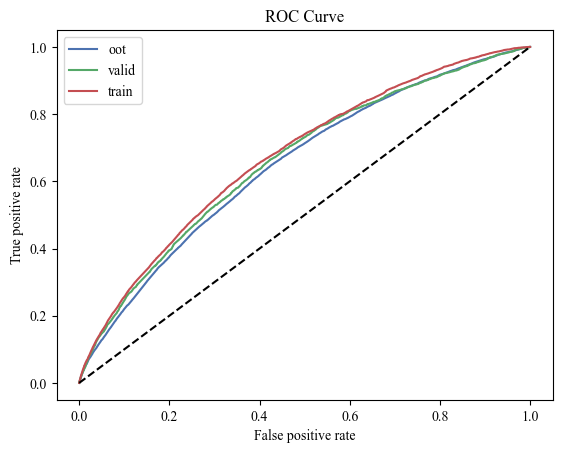

In [56]:
from ScoreCard.evaluation import ScorecardEvaluation
se = ScorecardEvaluation('信贷')
res_data = se.eval_dataset(data_end, model, keep_lst, col_name='target')

  datasets       auc  precision    recall        ks        f2        th  \
0  2024-09  0.672193   0.040558  0.472242  0.257133  0.150939  0.254672   
0  2024-10  0.668426   0.037587  0.431791  0.244873  0.139398  0.257260   
0  2024-11  0.642987   0.033497  0.374587  0.212767  0.123359  0.263730   
0  2024-12  0.692297   0.042157  0.399569  0.293019  0.148228  0.278449   
0  2025-01  0.626388   0.037315  0.574592  0.189284  0.148101  0.212520   

      ratio   count  
0  0.248530  200000  
0  0.222593  300000  
0  0.203003  300000  
0  0.176010  100000  
0  0.396360  100000  
  datasets       auc        ks  precision    recall        f2        th  \
0  2024-09  0.672193  0.257133   0.040558  0.472242  0.150939  0.254672   
0  2024-10  0.668426  0.244873   0.037587  0.431791  0.139398  0.257260   
0  2024-11  0.642987  0.212767   0.033497  0.374587  0.123359  0.263730   
0  2024-12  0.692297  0.293019   0.042157  0.399569  0.148228  0.278449   
0  2025-01  0.626388  0.189284   0.037315 

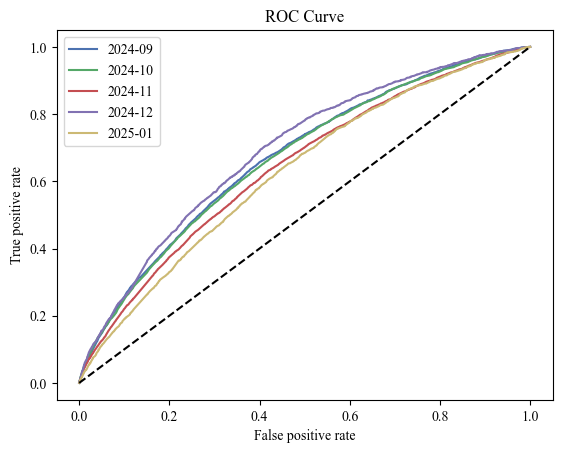

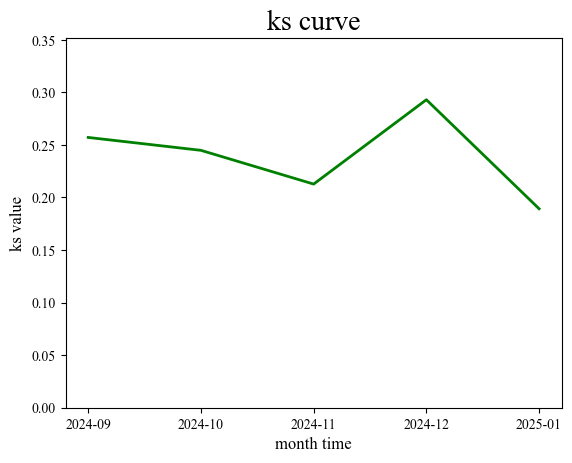

In [57]:
res_month = se.eval_month(data_end, model, keep_lst, col_name='month_time')

In [58]:
importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_})
importance.sort_values(by='importance', ascending=False)

,var_names,importance
1,proba_name2,0.559569
0,proba_name1,0.440431


### 分数评估

In [59]:
end_keep = list(importance[importance['importance']>0]['var_names'])
len(end_keep)

2

In [60]:
from new_tools import auto_score
# 开始分数转换
scorer = auto_score.ScoreCalculator(max_score=900, min_score=300)  # 实例化分数计算器
data_end['proba'] =  model.predict_proba(data_end[keep_lst])[:, 1]
scores, min_score, max_score, final_p, final_q, final_pdo = scorer.automatic_scoring(data_end['proba'])
data_end['score'] = scores

pdo_df = pd.DataFrame({'Min Score': min_score,
                        'Max Score': max_score,
                        'P': final_p,
                        'Q': final_q,
                        'PDO': final_pdo},index=[0])
# 打印结果
print(f"Min Score: {min_score}, Max Score: {max_score}, P: {final_p}, Q: {final_q}, PDO: {final_pdo}")

def card_score(pred, P=final_p, Q=final_q, PDO=final_pdo, good_weight=1):
    '''
    根据概率1返回卡评分
    pred:概率(array或scalar); Q:设定的Odds比率; P:比率Q时的分数
    PDO:比率为2Q时分值增加量; good_weight:好客户抽样比例
    '''
    Odds = (1-pred)*good_weight/pred
    B = -PDO/np.log(2)
    A = P + B*np.log(Q)
    score = A - B*np.log(Odds)
    # score[score<350] = 350
    # score[score>850] = 1000
    return score.astype(int)
	
data_end['score'] = card_score(data_end['proba'])

print(data_end['proba'].min(),data_end['proba'].max())
print(data_end['score'].min(),data_end['score'].max())
data_end[['score','proba']].head()

Min Score: 346, Max Score: 892, P: 700, Q: 10, PDO: 80
0.018494606 0.68106407
346 892


,score,proba
0,546,0.274274
1,541,0.283301
2,596,0.196354
3,613,0.175239
4,485,0.391772


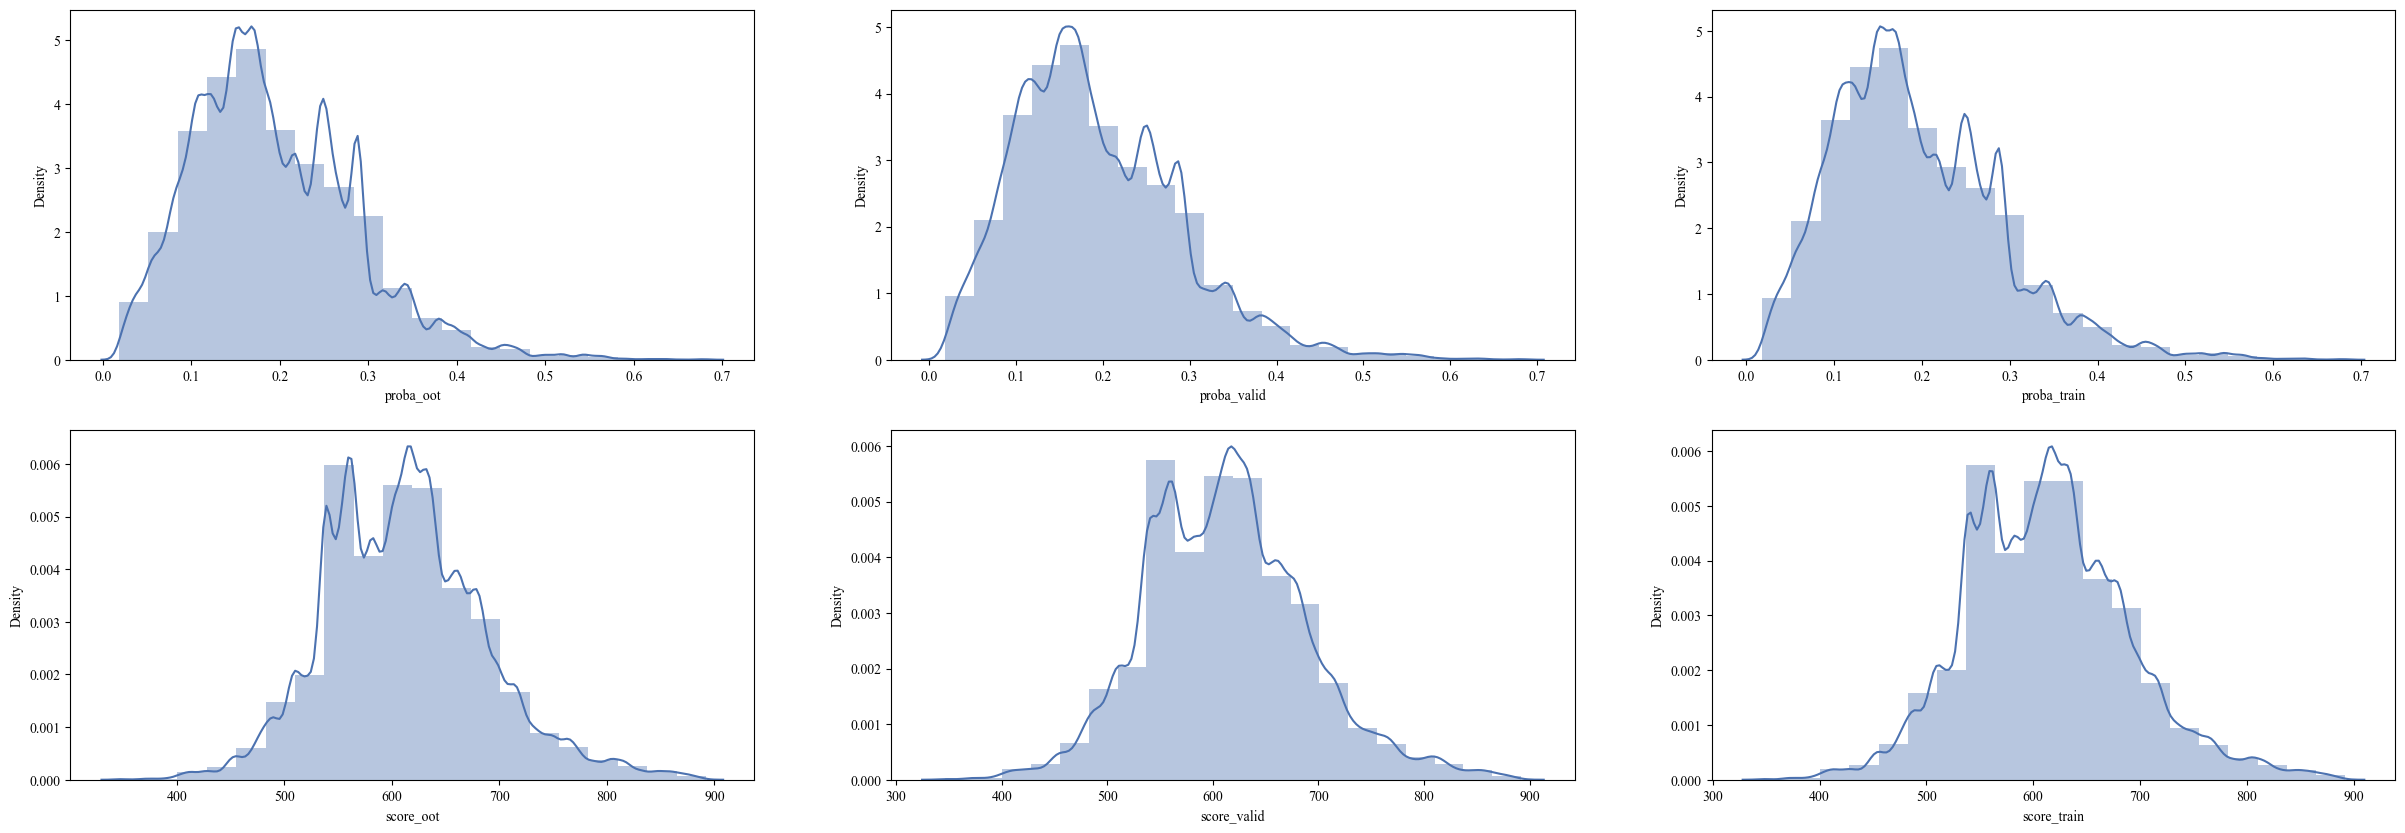

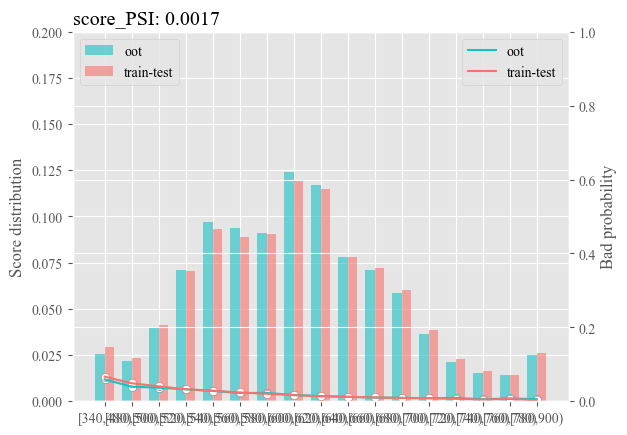

In [61]:
plt.style.use('seaborn-deep')
plt.rcParams['font.sans-serif'] = 'Times New Roman'
se.plot_distribution(data_end, bin_num=20, x_tick_break=20, col_name='target')

In [62]:
# se.plot_psi(data_end)

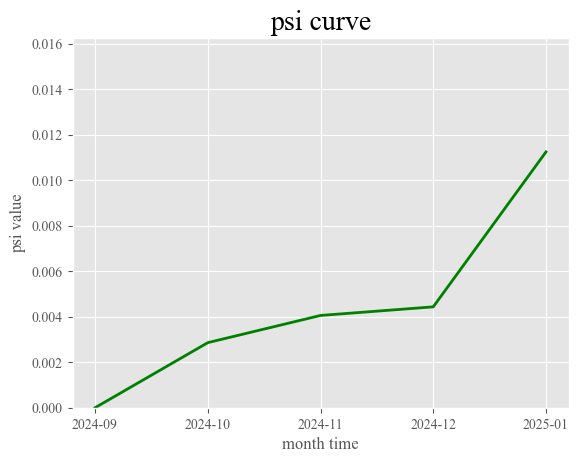

,moth,psi
0,2024-09,0.000000
1,2024-10,0.002859
2,2024-11,0.004054
3,2024-12,0.004432
4,2025-01,0.011240


In [63]:
from new_tools.new_psi import plot_month_psi_curve
plot_month_psi_curve(data_end, 'month_time')

In [64]:
import toad
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='train']['score'], data_end[data_end['target']=='train']['label'], 
                                   bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_train.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,346,521,0.051245,0.054013,0.241204,0.094924,2.541022,2.541022
1,522,548,0.031643,0.032677,0.401857,0.197315,1.569011,2.036624
2,549,566,0.027248,0.028011,0.536757,0.297161,1.351089,1.806285
3,567,590,0.022277,0.022784,0.646654,0.396650,1.104607,1.630287
4,591,610,0.017517,0.017830,0.733643,0.496798,0.868608,1.476743
5,611,627,0.014728,0.014948,0.806857,0.597051,0.730295,1.351404
6,628,646,0.014201,0.014405,0.878125,0.698262,0.704158,1.257588
7,647,673,0.010860,0.010979,0.932026,0.798355,0.538500,1.167433
8,674,709,0.008720,0.008797,0.975595,0.899122,0.432379,1.085054
9,710,892,0.004879,0.004903,1.000000,1.000000,0.241924,1.000000


In [65]:
score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='valid']['score'], data_end[data_end['target']=='valid']['label'],
                                                                     bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                  )
score_ks.to_csv(FILE_PATH + 'score_ks_valid.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,346,521,0.048486,0.050956,0.229829,0.095614,2.403728,2.403728
1,522,548,0.030958,0.031947,0.387356,0.198251,1.534786,1.953863
2,549,566,0.026776,0.027512,0.519036,0.297451,1.327425,1.744946
3,567,590,0.022356,0.022868,0.629060,0.396721,1.108334,1.585649
4,591,611,0.019344,0.019725,0.727908,0.499796,0.958988,1.456411
5,612,628,0.015633,0.015881,0.805449,0.599848,0.775006,1.342755
6,629,646,0.012126,0.012275,0.864129,0.697455,0.601181,1.238974
7,647,673,0.009573,0.009665,0.911631,0.797550,0.474578,1.143040
8,674,709,0.009640,0.009734,0.960182,0.899138,0.477915,1.067892
9,710,892,0.007963,0.008027,1.000000,1.000000,0.394779,1.000000


In [66]:

score_ks =  toad.metrics.KS_bucket(data_end[data_end['target']=='oot']['score'], data_end[data_end['target']=='oot']['label'],
                                bucket=10,
#                                    q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,]
                                )
score_ks.to_csv(FILE_PATH + 'score_ks_oot.csv')
score_ks[['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','lift','cum_lift']]

,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,lift,cum_lift
0,346,525,0.042640,0.044539,0.214649,0.099527,2.156696,2.156696
1,526,550,0.030715,0.031688,0.369780,0.199384,1.553531,1.854614
2,551,566,0.025360,0.026019,0.495344,0.297277,1.282670,1.666273
3,567,590,0.022855,0.023389,0.612940,0.399005,1.155982,1.536172
4,591,609,0.019147,0.019521,0.703273,0.492280,0.968460,1.428604
5,610,626,0.015783,0.016036,0.788903,0.599547,0.798284,1.315832
6,627,643,0.013802,0.013995,0.857541,0.697868,0.698095,1.228800
7,644,670,0.011182,0.011308,0.914275,0.798183,0.565563,1.145445
8,671,706,0.009552,0.009645,0.963041,0.899116,0.483155,1.071098
9,707,892,0.007243,0.007296,1.000000,1.000000,0.366350,1.000000


In [67]:
score_ks = se.show_statistic(data_end, bin_num=10, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 524.0, 550.0, 567.0, 591.0, 611.0, 627.0, 646.0, 673.0, 707.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,524.0,0.046247,20.623043,0.230472,0.099466,99466.0,0.133674,2.317098,1.000000,0.019959
1,524.0,550.0,0.030671,31.604064,0.383336,0.198941,99475.0,0.188150,1.926882,0.900534,0.017055
2,550.0,567.0,0.026240,37.109302,0.512601,0.297263,98322.0,0.219723,1.724402,0.801059,0.015365
3,567.0,591.0,0.022596,43.255937,0.626534,0.397901,100638.0,0.233290,1.574599,0.702737,0.013843
4,591.0,611.0,0.018470,53.142400,0.720477,0.499418,101517.0,0.225561,1.442633,0.602099,0.012380
5,611.0,627.0,0.015444,63.750503,0.795180,0.595961,96543.0,0.203276,1.334282,0.500582,0.011145
6,627.0,646.0,0.013760,71.675334,0.866476,0.699378,103417.0,0.170501,1.238924,0.404039,0.010118
7,646.0,673.0,0.010870,90.995383,0.920738,0.799009,99631.0,0.124208,1.152349,0.300622,0.008865
8,673.0,707.0,0.009284,106.716336,0.966131,0.896600,97591.0,0.070947,1.077549,0.200991,0.007871
9,707.0,inf,0.006538,151.958580,1.000000,1.000000,103400.0,0.000000,1.000000,0.103400,0.006538


In [68]:
score_ks = se.show_statistic(data_end[data_end['target']=='oot'], bin_num=10, q=None)
flag = '信贷'
show_lst = ['min','max','bad_rate','odds','cum_bads_prop','cum_total_prop','total','ks','cum_lift','通过率']
show_lst += ['通过人群整体坏账率'] if flag != '营销' else ['通过人群整体响应率']
score_ks[show_lst]

[-inf, 526.0, 551.0, 567.0, 591.0, 610.0, 627.0, 644.0, 671.0, 707.0, inf]


,min,max,bad_rate,odds,cum_bads_prop,cum_total_prop,total,ks,cum_lift,通过率,通过人群整体坏账率
0,-inf,526.0,0.042640,22.452147,0.214649,0.099527,52439.0,0.117444,2.156696,1.000000,0.019771
1,526.0,551.0,0.030715,31.557550,0.369780,0.199384,52613.0,0.173833,1.854614,0.900473,0.017243
2,551.0,567.0,0.025360,38.432722,0.495344,0.297277,51578.0,0.202063,1.666273,0.800616,0.015563
3,567.0,591.0,0.022855,42.754286,0.612940,0.399005,53599.0,0.218250,1.536172,0.702723,0.014198
4,591.0,610.0,0.019147,51.226355,0.703273,0.492280,49145.0,0.215249,1.428604,0.600995,0.012733
5,610.0,627.0,0.015783,62.359865,0.788903,0.599547,56517.0,0.193175,1.315832,0.507720,0.011555
6,627.0,644.0,0.013802,71.453147,0.857541,0.697868,51804.0,0.162893,1.228800,0.400453,0.010422
7,644.0,671.0,0.011182,88.431472,0.914275,0.798183,52854.0,0.118433,1.145445,0.302132,0.009322
8,671.0,707.0,0.009552,103.685039,0.963041,0.899116,53180.0,0.065214,1.071098,0.201817,0.008398
9,707.0,inf,0.007243,137.062338,1.000000,1.000000,53154.0,0.000000,1.000000,0.100884,0.007243


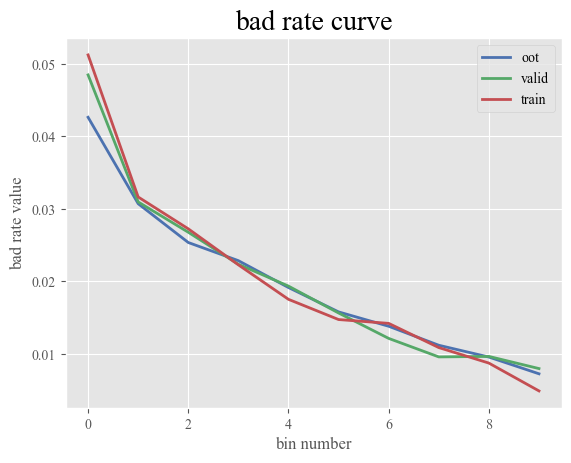

In [69]:
plt.style.use('seaborn-deep')
plt.rcParams['font.sans-serif'] = 'Times New Roman'
se.plot_badrate(data_end, bin_num=10, col_name='target')

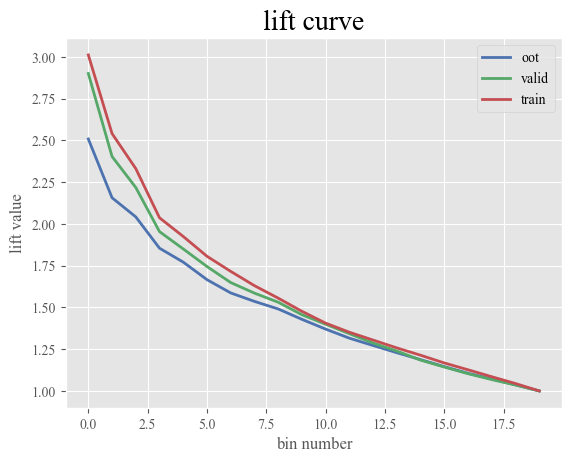

In [70]:
se.plot_lift(data_end, bin_num=20, col_name='target')

### 文件导出

In [71]:
SAVE_PATH = FILE_PATH + '上线文档/'
isExists = os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

#### 原始文件

In [ ]:
data_org = data_all.copy()
data_org['backDateTime'] = pd.to_datetime(data_org['backDateTime'])
data_org1 = data_end[data_end['target'].isin(['valid', 'train'])].iloc[:1000, :][['mobile','label','backDateTime']]
data_org1.to_csv(SAVE_PATH + '原始文档.csv', index=False, encoding='utf-8-sig')

In [73]:
data_org1

,mobile_sha256,label,hs_date
2,4d4d2304e9265b029491e1fec60e7431d55285fcad426e...,0.0,2024-10-03
3,f05c3b1367d78a5da0b060110d8724e72664c86dc456a4...,0.0,2024-10-24
5,db24107ae7d0af41da86815a2036bc174b6ede7e2e71f6...,0.0,2024-10-08
9,e3c4d9e0ae3dd90ec08e5f6264feb2e51825dee86eaa3e...,0.0,2024-10-14
10,ff80732b52fb08b46b72a562bea9544b91d8168c236d71...,0.0,2024-09-07
...,...,...,...
2112,308b65f3d4a3d7165e2db83ff0c3723a363bff009c5526...,0.0,2024-09-19
2115,5cd2a162e5969456ce97ba49e471bedbe20cd2a4c72969...,0.0,2024-10-17
2116,cd95c2387bd13742ba15ef8e7491d025804d6b35cd9648...,0.0,2024-10-12
2117,7539b27bc5b8dc03991e799c5b3cc917c746d37c8db6bf...,0.0,2024-10-17


#### 对照文件

In [74]:
data_comp = data_end[data_end['target'].isin(['valid', 'train'])].iloc[:1000, :]
data_comp.to_csv(SAVE_PATH + '对照文档.csv', index=False, encoding='utf-8-sig')
data_comp

,proba_name1,proba_name2,mobile_sha256,stage,label,hs_date,target,month_time,weight,proba,score,bucket
2,0.272476,0.048015,4d4d2304e9265b029491e1fec60e7431d55285fcad426e...,train,0.0,2024-10-03,valid,2024-10,1,0.196354,596,4
3,0.391101,0.023600,f05c3b1367d78a5da0b060110d8724e72664c86dc456a4...,train,0.0,2024-10-24,train,2024-10,1,0.175239,613,5
5,0.242599,0.016729,db24107ae7d0af41da86815a2036bc174b6ede7e2e71f6...,train,0.0,2024-10-08,train,2024-10,1,0.095519,693,8
9,0.226089,0.026389,e3c4d9e0ae3dd90ec08e5f6264feb2e51825dee86eaa3e...,train,0.0,2024-10-14,train,2024-10,1,0.104205,682,8
10,0.214203,0.022504,ff80732b52fb08b46b72a562bea9544b91d8168c236d71...,train,0.0,2024-09-07,train,2024-09,1,0.098822,689,8
...,...,...,...,...,...,...,...,...,...,...,...,...
2112,0.415033,0.050999,308b65f3d4a3d7165e2db83ff0c3723a363bff009c5526...,train,0.0,2024-09-19,train,2024-09,1,0.252458,559,2
2115,0.353704,0.056760,5cd2a162e5969456ce97ba49e471bedbe20cd2a4c72969...,train,0.0,2024-10-17,train,2024-10,1,0.283301,541,1
2116,0.184450,0.018368,cd95c2387bd13742ba15ef8e7491d025804d6b35cd9648...,train,0.0,2024-10-12,train,2024-10,1,0.059931,751,9
2117,0.197644,0.018364,7539b27bc5b8dc03991e799c5b3cc917c746d37c8db6bf...,train,0.0,2024-10-17,valid,2024-10,1,0.059488,752,9


#### 模型pmml文件

In [ ]:
# from sklearn2pmml import sklearn2pmml, PMMLPipeline
# from sklearn.pipeline import make_pipeline
# # from nyoka import xgboost_to_pmml

# flag = 1

# if flag:
#     train = data_end[data_end['target']=='train']

#     pipeline = PMMLPipeline([("classifier", model)])
#     pipeline.fit(train[keep_lst], train['label'])

#     sklearn2pmml(pipeline, SAVE_PATH + 'xgb_model.pmml', with_repr=True)
#     # xgboost_to_pmml(pipeline, keep_lst, 'label', SAVE_PATH + 'xgb_model.pmml')
# else:
#     model.save_model( SAVE_PATH + 'xgb_model')

Exception in thread Thread-7:
Traceback (most recent call last):
  File "d:\miniconda3\envs\p_3_8\lib\threading.py", line 932, in _bootstrap_inner
    self.run()
  File "d:\miniconda3\envs\p_3_8\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "d:\miniconda3\envs\p_3_8\lib\threading.py", line 870, in run
    self._target(*self._args, **self._kwargs)
  File "d:\miniconda3\envs\p_3_8\lib\subprocess.py", line 1386, in _readerthread
    buffer.append(fh.read())
  File "d:\miniconda3\envs\p_3_8\lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd4 in position 1: invalid continuation byte


In [76]:
model.save_model( SAVE_PATH + 'model.json')

In [77]:
import joblib
joblib.dump(model, SAVE_PATH + 'model.model')

['D:\\work\\03.poc\\01-马上消费\\AlphaV3-ThetaV2_CA_target1\\file/上线文档/model.model']

In [78]:
pd.DataFrame({'var_names': keep_lst}).to_csv(SAVE_PATH + 'keep_lst.csv')

In [ ]:
if_single_ks = False
if_single_lift = False
# 建模报告输出
SAVE_PATH = FILE_PATH + '建模报告/'
isExists=os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

# 新增自动报告输出  但是这里还需要改
# 计算train和oot的psi值
from new_tools import new_psi
keep_list = keep_lst

psi_df_tv_o = new_psi.psi_for_continue_var(data_end[data_end['target'].isin(['train','valid'])]['proba'],
                                        data_end[data_end['target'].isin(['oot'])]['proba'],
                                        detail=True,method='equal_width')
psi_df_tv_o
psi_month = data_end['month_time'].min()
psi_df_month = new_psi.choice_month_psi(data_end,psi_month,'proba','month_time')
psi_df_month

df_list = []
temp_df = pd.DataFrame({
    'dataset':'all',
    'count':data_end['label'].count(),
    'bad_count':int(data_end['label'].sum()),
    'badrate':data_end['label'].mean(),
    'day_min':data_end['day_time'].min(),
    'day_max':data_end['day_time'].max()
},index=[0])
df_list.append(temp_df)

for col in ['target','month_time']:
    temp_df = data_end.groupby(col).agg({'label':['count','sum','mean'],'day_time':['min','max']}).reset_index()
    temp_df.columns = ['dataset','count','bad_count','badrate','day_min','day_max']
    temp_df.sort_values(by='dataset',ascending=True,inplace=True)
    df_list.append(temp_df)
info_df = pd.concat(df_list,axis=0,ignore_index=True)
info_df['bad_count'] = info_df['bad_count'].astype(int)
info_df['time_range'] = info_df['day_min'] +' ~ '+ info_df['day_max']
info_df.drop(['day_max','day_min'],axis=1,inplace=True)
info_df

import toad
tag_list = [['train'],['valid'],['oot']]
tag_list_str = [str(i) for i in tag_list]
df_list = []

for tag in tag_list:
    temp_df = data_end[data_end['target'].isin(tag)]
    score_ks =  toad.metrics.KS_bucket(temp_df['proba'],
                                        temp_df['label'], 
                                        bucket=10,
                                        )
    lift_df_diff = score_ks[['min','max','lift','cum_lift']]
    df_list.append(lift_df_diff)

lift_df = pd.concat(df_list,axis=1,keys=tag_list_str)
lift_df

from new_tools import iv_report

iv_calculator = iv_report.IVCalculator(data_end,label='label',target='target',keep_list=keep_list)
iv_df = iv_calculator.iv_report(use_thread=True,max_workers=20)
iv_df.sort_values(by='train_iv',ascending=False,inplace=True)
iv_df.to_excel(SAVE_PATH + 'iv_report.xlsx',index=False)
ipt_df = pd.DataFrame({'var_name': keep_list, 'importance': model.feature_importances_})
ipt_df.sort_values(by='importance', ascending=False, inplace=True)
ipt_iv_df = pd.merge(ipt_df,iv_df,on='var_name',how='left')
ipt_iv_df.to_excel(SAVE_PATH+'ipt_iv.xlsx',index=False)

iv_detail_df = iv_calculator.detail_report(ipt_iv_df['var_name'],'all')


if if_single_ks:
    # 基于配置参数，来决定是否进行输出
    ipt_iv_df = pd.merge(ipt_iv_df,iv_detail_df[['var_name','ks']].drop_duplicates(subset=['var_name']),on='var_name',how='left')
    ipt_iv_df['ks'] = ipt_iv_df['ks'].fillna(0)
iv_detail_df.drop(columns=['ks','badCumRate','goodCumRate'],inplace=True)

if if_single_lift:
    # 基于配置参数，来决定是否进行输出
    def calc_lift(df):
        total_bad = df['bad'].sum()
        total_cnt = df['total'].sum()
        overall_bad_rate = total_bad / total_cnt
        df['lift'] = df['bad_rate'] / overall_bad_rate
        
        return df

    iv_detail_df = iv_detail_df.groupby('var_name', group_keys=False).apply(calc_lift)


import re

def extract_left(bin_str):
    """从区间字符串中提取左端点数值"""
    try:
        left = re.findall(r'[\[\(](-inf|-?\d+\.?\d*)', str(bin_str))[0]
        return float('-inf') if left == '-inf' else float(left)
    except IndexError:
        return float('inf')  # 异常值放最后

iv_detail_df = iv_detail_df.sort_values(
    by=['var_name', 'bin'],
    key=lambda s: s if s.name == 'var_name' else s.map(extract_left),
    ascending=[True, True]  # var_name升序，bin升序
)


model_performance_ks = pd.concat([res_data[['datasets','auc','ks']], res_month[['datasets','auc','ks']]])
def calc_lift(group):
    high_thr = group['score'].quantile(0.95)
    low_thr = group['score'].quantile(0.05)
    top5 = group[group['score'] >= high_thr]
    bottom5 = group[group['score'] <= low_thr]
    bad_rate_all = (group['label'] == 1).mean()
    bad_rate_top5 = (top5['label'] == 1).mean()
    bad_rate_bottom5 = (bottom5['label'] == 1).mean()
    lift_top5 = bad_rate_top5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    lift_bottom5 = bad_rate_bottom5 / bad_rate_all if bad_rate_all > 0 else float('nan')
    return pd.Series({'sub_5_lift': lift_top5,'top_5_lift': lift_bottom5})

result_data = data_end.groupby('target').apply(calc_lift).reset_index()
result_month = data_end.groupby('month_time').apply(calc_lift).reset_index()
result_data.rename(columns={'target':'datasets'},inplace=True)
result_month.rename(columns={'month_time':'datasets'},inplace=True)
model_performance_lift = pd.concat([result_data,result_month])
eval_df = pd.merge(model_performance_ks,model_performance_lift,on='datasets',how='left')


with pd.ExcelWriter(SAVE_PATH + '模型评估报告.xlsx') as writer:
    info_df.to_excel(writer, sheet_name='数据概要', index=False)
    eval_df.to_excel(writer, sheet_name='模型性能', index=True)
    ipt_iv_df.to_excel(writer, sheet_name='特征重要性', index=False)
    iv_detail_df.to_excel(writer, sheet_name='特征分箱', index=False)
    lift_df.to_excel(writer, sheet_name='lift', index=True)
    psi_df_tv_o.to_excel(writer, sheet_name='psi_训练与oot', index=False)
    psi_df_month.to_excel(writer, sheet_name='psi_逐月', index=False)
    pdo_df.to_excel(writer, sheet_name='打分参数', index=False)

初始化IV计算器,获取各个数据集的索引...
初始化完成


计算在所有数据集上的IV分箱细节: 100%|██████████| 2/2 [00:00<00:00,  8.41it/s]


In [80]:
SAVE_PATH = FILE_PATH + '建模报告/'
isExists=os.path.exists(SAVE_PATH)
if not isExists:
    os.makedirs(SAVE_PATH) 

In [81]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
key_value = pd.read_excel(FILE_PATH + 'key_value.xlsx')
key_value = key_value[key_value['var_names'].isin(keep_lst)]
result = pd.merge(feature_importance, key_value, on='var_names')
result.to_csv(SAVE_PATH + 'ipt_iv_psi.csv', index=False, encoding='utf-8-sig')

In [82]:
feature_importance = pd.DataFrame({'var_names': keep_lst, 'importance': model.feature_importances_}).sort_values(by='importance', ascending=False)
feature_importance = feature_importance[feature_importance['var_names'].isin(end_keep)]
key_value = pd.read_excel(FILE_PATH + 'bins_detail.xlsx')
key_value = key_value[key_value['variable'].isin(end_keep)]
result = pd.merge(feature_importance, key_value, left_on='var_names',right_on='variable')
result.to_csv(SAVE_PATH + 'bin_details.csv', index=False, encoding='utf-8-sig')

### new report part

In [ ]:
# new_report part
from utils.excel_utils import *
from utils.hello_score_bucket import *
from new_tools.feature_ks_report import month_ks_report
# new_report part

# sheet1
info_df_new = info_df.copy()
info_df_new.rename(columns={'dataset':'建模样本','count':'样本量','bad_count':'坏样本量','badrate':'样本坏率','time_range':'时间段'},inplace=True)
info_df_filtered = info_df_new[info_df_new['建模样本'].isin(['oot', 'valid', 'train'])] #table2
custom_order = ['train', 'valid', 'oot']
order_mapping = {value: index for index, value in enumerate(custom_order)}
info_df_filtered['temp_sort'] = info_df_filtered['建模样本'].map(order_mapping)
info_df_filtered.sort_values('temp_sort', ascending=True, inplace=True)
info_df_filtered.drop('temp_sort', axis=1, inplace=True)
info_df_month_bad_rate = info_df_new[~info_df_new['建模样本'].isin(['oot', 'valid', 'train'])][['建模样本','样本坏率']]
info_df_month_bad_rate.sort_values('建模样本',ascending=True,inplace=True) #table1

eval_df_new = eval_df.copy()
eval_df_new1 = eval_df_new[eval_df_new['datasets'].isin(['oot', 'valid', 'train'])]
eval_df_new1 = eval_df_new1.T.reset_index()
eval_df_new1.columns = eval_df_new1.iloc[0]  # Set first row as column names
eval_df_new1 = eval_df_new1[1:] 
eval_df_new1.rename(columns={'datasets':'模型性能'},inplace=True) #table3

# sheet2
#table1
psi_df_month_new = psi_df_month.copy()
psi_df_month_new['月环比'] = (psi_df_month_new['psi'] - psi_df_month_new['psi'].diff())/psi_df_month_new['psi']
psi_df_month_new.fillna('/',inplace=True)

#table2
score_ks,spilt_bins =  toad.metrics.KS_bucket(data_end['score'], data_end['label'], bucket=10, return_splits='True',method='step')
month_list = list(data_end['month_time'].value_counts().index)
month_list.sort()
bin_count_month = score_bucket(data_end[data_end['month_time']==month_list[1]],method='step',bucket=spilt_bins)[['bins','all']]
bin_count_month.rename(columns = {'all':month_list[0]},inplace=True)
bin_count_month
for month in month_list[1:]:
    bin_count_month = bin_count_month.merge(score_bucket(data_end[data_end['month_time']==month],method='step',bucket=spilt_bins)[['bins','all']],on='bins',how='left')
    bin_count_month.rename(columns = {'all':month},inplace=True)
bin_count_month.fillna(0,inplace=True)
numeric_cols = bin_count_month.columns[1:]
def divide_by_total(row, total_row):
    # if row['bins'] == '合计':
    #     return row  
    # else:
    row[numeric_cols] = row[numeric_cols] / total_row[numeric_cols].values
    return row
total_row = bin_count_month[bin_count_month['bins'] == '合计'].iloc[0]
bin_count_month = bin_count_month.apply(divide_by_total, axis=1, total_row=total_row)
bin_count_month = bin_count_month[bin_count_month['bins'] != '合计']
bin_count_month.rename(columns={'bins':'样本分布'},inplace=True)



#table3-7
eval_df_month = eval_df[~eval_df['datasets'].isin(['oot', 'valid', 'train'])]

eval_df_month_ks = eval_df_month[['datasets','ks']]
eval_df_month_sub5lift = eval_df_month[['datasets','sub_5_lift']]
eval_df_month_top5lift = eval_df_month[['datasets','top_5_lift']]
eval_df_month_sub10lift = eval_df_month[['datasets','sub_10_lift']]
eval_df_month_top10lift = eval_df_month[['datasets','top_10_lift']]

#table3
eval_df_month_ks.rename(columns={'datasets':'KS'},inplace=True)

#table4
eval_df_month_sub5lift.rename(columns={'datasets':'尾部5%lift'},inplace=True)

#table5
eval_df_month_sub10lift.rename(columns={'datasets':'尾部10%lift'},inplace=True)

#table6
eval_df_month_top5lift.rename(columns={'datasets':'头部5%lift'},inplace=True)

#table7
eval_df_month_top10lift.rename(columns={'datasets':'头部10%lift'},inplace=True)

#sheet3
def drop_some_columns(df,drop_columns):
    df.drop(columns=drop_columns,inplace=True)
    return df

#table1-2
score_ks_train_quantile = drop_some_columns(score_bucket(data_end[data_end['target']=='train'],method='quantile',bucket=10),['等频/等距','y标','分箱数'])
score_ks_train_step = drop_some_columns(score_bucket(data_end[data_end['target']=='train'],method='step',bucket=10),['等频/等距','y标','分箱数'])

#table3-4
score_ks_valid_quantile = drop_some_columns(score_bucket(data_end[data_end['target']=='valid'],method='quantile',bucket=10),['等频/等距','y标','分箱数'])
score_ks_valid_step = drop_some_columns(score_bucket(data_end[data_end['target']=='valid'],method='step',bucket=10),['等频/等距','y标','分箱数'])

#table5-6
score_ks_oot_quantile = drop_some_columns(score_bucket(data_end[data_end['target']=='oot'],method='quantile',bucket=10),['等频/等距','y标','分箱数'])
score_ks_oot_step = drop_some_columns(score_bucket(data_end[data_end['target']=='oot'],method='step',bucket=10),['等频/等距','y标','分箱数'])

#sheet4

report = Report(data_end[keep_lst + ex_lst], ex_lst, 'label', FILE_PATH + 'new_' )
key_value_new, bins_detail_new, train, oot = report.iv_ks_psi_chi2_missing_quantile(if_train_oot=True) 

def feature_report(feature_name,df):

    test_df = pd.pivot_table(df[[feature_name,'label']].value_counts().reset_index(),columns='label',index=feature_name,values=0).reset_index()
    test_df.columns = ['value','Non-event','Event']
    test_df['Count'] = test_df.iloc[:, 1:].sum(axis=1)
    col_sums = test_df.iloc[:, 1:].sum(axis=0)
    col_sums.name = 'col_sum'
    col_sums_df = pd.DataFrame([col_sums])
    col_sums_df.insert(0,'value','Total')
    result_df = pd.concat([test_df, col_sums_df], ignore_index=True)
    result_df['Count(%)'] = result_df['Count'] / result_df['Count'].iloc[-1]
    result_df.insert(0,'特征名',feature_name)
    result_df['Event rate'] = result_df['Event'] / result_df['Count']
    result_df = result_df[['value','特征名','Count','Count(%)','Non-event','Event','Event rate']]
    # result_df.insert(1,'中文注释','')
    # result_df.insert(0, '序号', result_df.index)
    return result_df

def move_column_to_position(df, column_name, position):
    """将指定列移动到指定位置"""
    cols = list(df.columns)
    cols.remove(column_name)
    cols.insert(position, column_name)
    return df[cols]

tmp_bins_detail_new = bins_detail_new[['variable','value','bin']]
tmp_bins_detail_new.rename(columns={'variable':'特征名'},inplace=True)


feature_report_list = []
for feature_name in keep_lst:
    train_df = feature_report(feature_name,train)
    oot_df = feature_report(feature_name,oot)
    result_df = pd.merge(train_df,oot_df,on=['value','特征名'])
    result_df = result_df.merge(tmp_bins_detail_new,on=['value','特征名'],how='left')
    result_df = move_column_to_position(result_df, 'bin', 2)
    result_df.rename(columns={'bin':'Bin','value':'序号'},inplace=True)
    feature_report_list.append(result_df)
feature_report_df = pd.concat(feature_report_list,ignore_index=True)

month_ks = []
month_list = list(data_end['month_time'].value_counts().index)
month_list.sort()
for the_month in month_list:
    month_ks_temp = month_ks_report(data_end, keep_lst, bins_detail_new, the_month)
    month_ks_temp.rename(columns={'max_ks':the_month},inplace=True)
    month_ks.append(month_ks_temp)
final_month_ks = month_ks[0]
for month_ks_df in month_ks[1:]:
    final_month_ks = final_month_ks.merge(month_ks_df)
# final_month_ks.to_csv(FILE_PATH + 'month_ks.csv', index=False, encoding='utf-8-sig')
final_month_ks.rename(columns={'variable':'var_names'},inplace=True)

# 分离数据
train_data = data_end[data_end['target'] == 'train']
oot_data = data_end[data_end['target'] == 'oot']

# 计算每个特征等于-999的数量
missing_count_train = [(train_data[fea] == -999).sum() for fea in keep_lst]
missing_count_oot = [(oot_data[fea] == -999).sum() for fea in keep_lst]

# 计算缺失率
missing_rate_train = [count / len(train_data) for count in missing_count_train]
missing_rate_oot = [count / len(oot_data) for count in missing_count_oot]

# 创建结果DataFrame
missing_df = pd.DataFrame({
    'var_names': keep_lst,
    # 'train缺失数量': missing_count_train,
    'train缺失率': missing_rate_train,
    # 'oot缺失数量': missing_count_oot,
    'oot缺失率': missing_rate_oot
})

# key_value_new[['var_names','iv_bin_total','psi_tv_bin','psi_to_bin','psi_vo_bin']]

# 合并多个DataFrame
ipt_df.rename(columns={'var_name':'var_names'},inplace=True)
result_df = ipt_df.merge(key_value_new[['var_names','iv_bin_total','psi_tv_bin','psi_to_bin','psi_vo_bin']], how='left', on='var_names')
result_df = result_df.merge(missing_df, how='left', on='var_names')
result_df = result_df.merge(final_month_ks, how='left', on='var_names')
result_df.rename(columns={'var_names':'特征名','importance':'重要性','iv_bin_total':'IV','psi_tv_bin':'train_test_psi','psi_to_bin':'train_oot_psi','psi_vo_bin':'test_oot_psi'},inplace=True)
result_df.insert(1,'特征类型','')
result_df.insert(1,'中文注释','')
result_df.insert(0, '序号', result_df.index)


# sheet5
score_ks_all = []
for i in [10,20,30,40,50]:
    for method in ['quantile','step']:
        score_ks = score_bucket(data_end[data_end['target']=='oot'],method=method,bucket=i)
        score_ks_all.append(score_ks)
score_ks_all = pd.concat(score_ks_all, ignore_index=True)
# score_ks_all.to_csv(FILE_PATH + 'score_ks_oot_all.csv',index=False)

# sheet6
score_ks_all_month = []
month_list = list(data_end['month_time'].value_counts().index)
month_list.sort()
for month in month_list:
    for i in [10,20,30,40,50]:
        for method in ['quantile','step']:
            score_ks = score_bucket(data_end[data_end['month_time']==month],method=method,bucket=i)
            score_ks.insert(0, '月份', str(month))
            score_ks.insert(0, '', score_ks.index)
            score_ks_all_month.append(score_ks)

score_ks_all_month = pd.concat(score_ks_all_month, ignore_index=True)
# score_ks_all_month.to_csv(FILE_PATH + 'score_ks_all_month.csv',index=False)

from utils.excel_utils import *


# 设置路径
excel_file = copy_report_config_to_save_path(SAVE_PATH, save_name = f'ronghe_{cust_name}_report.xlsx')

# 批量插入数据到Excel
insert_configs = [
    # sheet1 - 模型概述
    (info_df_month_bad_rate, 'A8', '模型概述', False, False),
    (info_df_filtered, 'A20', '模型概述', False, False),
    (eval_df_new1, 'A27', '模型概述', False, False),
    
    # sheet2 - 模型稳定性
    (psi_df_month_new, 'A4', '模型稳定性', False, False),
    (bin_count_month, 'A10', '模型稳定性', False, True),
    (eval_df_month_ks, 'A26', '模型稳定性', False, False),
    (eval_df_month_sub5lift, 'A34', '模型稳定性', False, False),
    (eval_df_month_sub10lift, 'A42', '模型稳定性', False, False),
    (eval_df_month_top10lift, 'A50', '模型稳定性', False, False),
    (eval_df_month_top5lift, 'A58', '模型稳定性', False, False),
    
    # sheet3 - 建模分箱
    (score_ks_train_quantile, 'A4', '建模分箱', False, False),
    (score_ks_train_step, 'A17', '建模分箱', False, False),
    (score_ks_valid_quantile, 'A33', '建模分箱', False, False),
    (score_ks_valid_step, 'A46', '建模分箱', False, False),
    (score_ks_oot_quantile, 'A62', '建模分箱', False, False),
    (score_ks_oot_step, 'A75', '建模分箱', False, False),
    
    # sheet4 - 入模特证
    (result_df, 'A2', '入模特证', False, True),
    (feature_report_df, 'A102', '入模特证', False, False),
    
    # sheet5 - 模型分oot分箱
    (score_ks_all, 'A2', '模型分oot分箱', False, True),
    
    # sheet6 - 模型分分月分箱
    (score_ks_all_month, 'A2', '模型分分月分箱', False, True)
]

# 执行批量插入
for df, start_cell, sheet_name, include_index, include_columns in insert_configs:
    insert_dataframe_to_excel_advanced(excel_file, df, start_cell, sheet_name, include_index, include_columns, preserve_format=True)